# 03 — Análisis exploratorio de datos (EDA)




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/streaming_users_clean.csv')
ORDEN_PLAN = ['Básico', 'Estándar', 'Premium']
df.head()

,user_id,age,subscription_plan,monthly_watch_time_mins,country,favorite_genre,last_login_date,customer_support_tickets
0,10000,39.0,Estándar,805.8,Brasil,Crime,2025-03-04,1.0
1,10001,37.0,Estándar,1173.4,Colombia,Crime,2019-04-02,2.0
2,10002,28.0,Básico,401.0,Colombia,Crime,2018-04-13,0.0
3,10003,43.0,Básico,62.4,Uruguay,Thriller,2021-01-31,0.0
4,10004,51.0,Básico,477.8,Perú,Thriller,2020-09-30,1.0


## Análisis univariado

### Pregunta 1 — ¿Cómo se distribuye la edad de los usuarios?


Media: 33.52   Mediana: 33.00   Moda: 13.0
Desvío: 11.71   Asimetría: 0.154


C:\Users\Ale\AppData\Local\Temp\ipykernel_1628\237701651.py:15: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df['age'], vert=False)


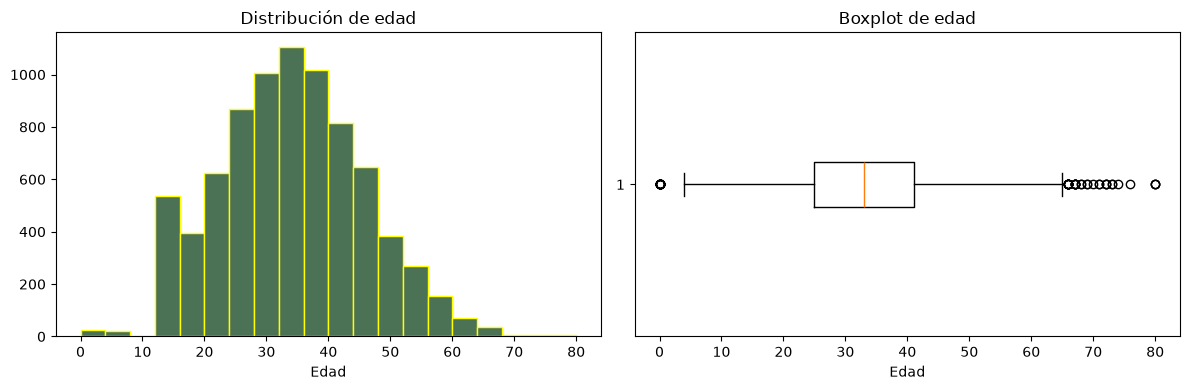

In [5]:
media = df['age'].mean()
mediana = df['age'].median()
moda = df['age'].mode()[0]
desvio = df['age'].std()
asimetria = df['age'].skew()

print(f"Media: {media:.2f}   Mediana: {mediana:.2f}   Moda: {moda}")
print(f"Desvío: {desvio:.2f}   Asimetría: {asimetria:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['age'], bins=20, color='#4C7255', edgecolor='yellow')
axes[0].set_title('Distribución de edad')
axes[0].set_xlabel('Edad')

axes[1].boxplot(df['age'], vert=False)
axes[1].set_title('Boxplot de edad')
axes[1].set_xlabel('Edad')

plt.tight_layout()
plt.show()

In [6]:
# La moda (13) no representa el centro real de la distribución: es un pico de frecuencia aislado.
vc_13 = df['age'].value_counts().sort_index().loc[10:20]
print("Frecuencia de age entre 10 y 20 años:")
print(vc_13)

Frecuencia de age entre 10 y 20 años:
age
13.0    385
14.0     70
15.0     83
16.0     85
17.0     92
18.0    106
19.0    111
20.0    136
Name: count, dtype: int64


**Interpretación:** la distribución de `age` es prácticamente simétrica (asimetría = 0.154,
media ≈ mediana ≈ 33 años), con usuarios entre 0 y 80 años. Esto responde la pregunta: el grueso
de la audiencia es adulta joven/adulta (Q1≈25, Q3≈41), sin un sesgo fuerte hacia un extremo.



### Pregunta 2 — ¿Qué plan de suscripción predomina?


                   Usuarios      %
subscription_plan                 
Básico                 3600  45.00
Estándar               2817  35.21
Premium                1583  19.79


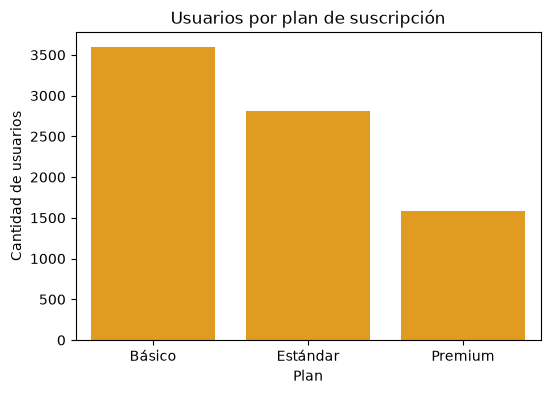

In [31]:
conteo_plan = df['subscription_plan'].value_counts().reindex(ORDEN_PLAN)
porcentaje_plan = (conteo_plan / len(df) * 100).round(2)

print(pd.DataFrame({'Usuarios': conteo_plan, '%': porcentaje_plan}))

plt.figure(figsize=(6, 4))
sns.barplot(x=conteo_plan.index, y=conteo_plan.values, order=ORDEN_PLAN, color="orange")
plt.title('Usuarios por plan de suscripción')
plt.ylabel('Cantidad de usuarios')
plt.xlabel('Plan')
plt.show()

**Interpretación:** el plan **Básico domina con 45%** de los usuarios, seguido por
Estándar (35.2%) y Premium (19.8%). La base de usuarios está concentrada en el plan de menor
costo — un dato relevante para cualquier decisión comercial: la mayoría de la audiencia no es,
todavía, la de mayor valor por suscripción.


## Análisis bivariado

### Pregunta 3 — ¿El plan de suscripción está asociado a mayor consumo?


                     mean  median    std
subscription_plan                       
Básico              597.0   552.7  459.0
Estándar            871.7   840.0  436.6
Premium            1138.5  1127.0  423.3


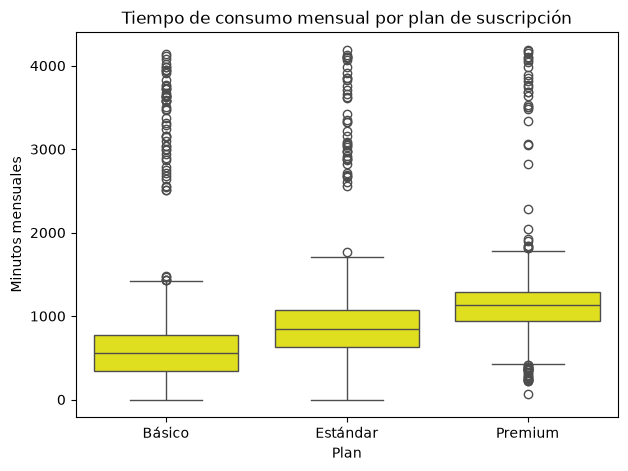

In [30]:
resumen_plan = df.groupby('subscription_plan')['monthly_watch_time_mins'].agg(['mean', 'median', 'std']).round(1).reindex(ORDEN_PLAN)
print(resumen_plan)

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='subscription_plan', y='monthly_watch_time_mins', order=ORDEN_PLAN, color="yellow")
plt.title('Tiempo de consumo mensual por plan de suscripción')
plt.xlabel('Plan')
plt.ylabel('Minutos mensuales')
plt.show()

**Interpretación:** sí — hay una relación clara y consistente: a medida que sube el plan,
sube el consumo. La mediana pasa de **553 min (Básico)** a **840 min (Estándar)** a
**1.127 min (Premium)**, prácticamente el doble entre los extremos. Esto responde la pregunta
de forma directa: el plan no es solo una etiqueta de precio, está asociado a un comportamiento
de consumo real y ordenado (Básico < Estándar < Premium en las tres medidas).


### Pregunta 4 — ¿Más tickets de soporte se asocian a menor consumo?


Correlación (Pearson): -0.0016
                            mean  count
customer_support_tickets               
0.0                        801.8   3563
1.0                        801.2   2915
2.0                        800.9   1157
3.0                        774.4    280
4.0                        800.8     71
5.0                       1029.5     14


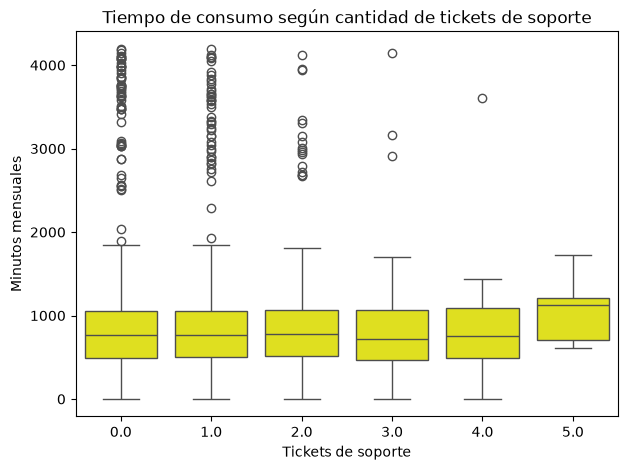

In [40]:
corr = df[['customer_support_tickets', 'monthly_watch_time_mins']].corr().iloc[0, 1]
print(f"Correlación (Pearson): {corr:.4f}")

resumen_tickets = df.groupby('customer_support_tickets')['monthly_watch_time_mins'].agg(['mean', 'count']).round(1)
print(resumen_tickets)

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='customer_support_tickets', y='monthly_watch_time_mins', color="yellow")
plt.title('Tiempo de consumo según cantidad de tickets de soporte')
plt.xlabel('Tickets de soporte')
plt.ylabel('Minutos mensuales')
plt.show()

**Interpretación:** **no** — la correlación es prácticamente nula (r = -0.0016), y el
consumo promedio se mantiene estable (~800 minutos) sin importar la cantidad de tickets
(0 a 4). El único grupo que se desvía (5 tickets, consumo más alto) representa solo 14 casos:
muy poca evidencia para sacar una conclusión. La hipótesis inicial — que más problemas de
soporte implican menor uso — **no se sostiene con estos datos**.

### Pregunta 5 — ¿El género favorito varía según el país?


favorite_genre  Acción  Comedia  Crime  Documental  Drama  Romance  Thriller
country                                                                     
Argentina         14.4     16.9   12.9        14.5   15.1     12.1      14.0
Brasil            12.6     18.2   13.1        13.8   13.8     14.0      14.4
Chile             14.4     16.1   15.2        13.2   13.6     14.1      13.4
Colombia          13.6     19.1   13.2        13.6   12.3     14.4      13.8
México            15.0     17.3   13.7        13.8   13.7     12.5      14.1
Perú              12.9     16.5   12.5        14.8   14.5     15.3      13.6
Uruguay           13.6     16.4   14.2        13.2   14.7     14.6      13.2


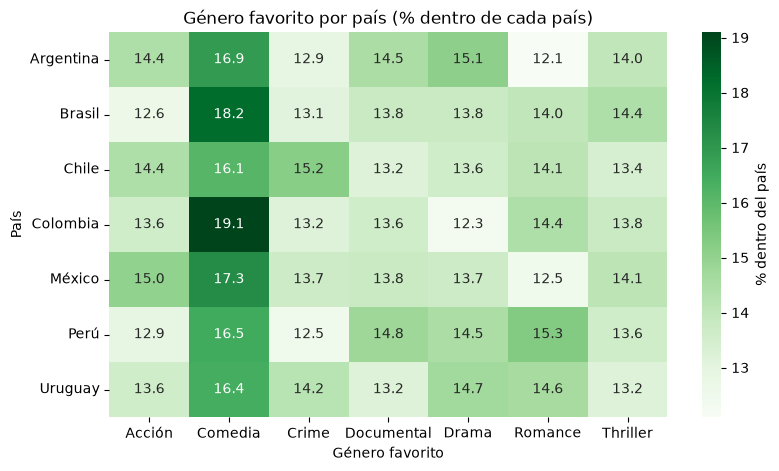

In [42]:
ct = pd.crosstab(df['country'], df['favorite_genre'], normalize='index').mul(100).round(1)
print(ct)

plt.figure(figsize=(9, 5))
sns.heatmap(ct, annot=True, fmt='.1f', cmap='Greens', cbar_kws={'label': '% dentro del país'})
plt.title('Género favorito por país (% dentro de cada país)')
plt.xlabel('Género favorito')
plt.ylabel('País')
plt.show()

**Interpretación:** no hay una preferencia marcada por país — las proporciones de cada
género se mantienen parecidas en los 7 países (diferencias menores a 3 puntos porcentuales en
casi todos los casos). **Comedia** es el género más elegido en todos los países (16% a 19%),
sin que ningún país se destaque con una preferencia propia. Para una decisión de catálogo,
esto sugiere que **no haría falta una curaduría de contenido específica por país** según esta
variable — el gusto por género parece transversal a la región.


## Análisis multivariado

### Pregunta 6 — ¿La relación edad-consumo cambia según el plan?


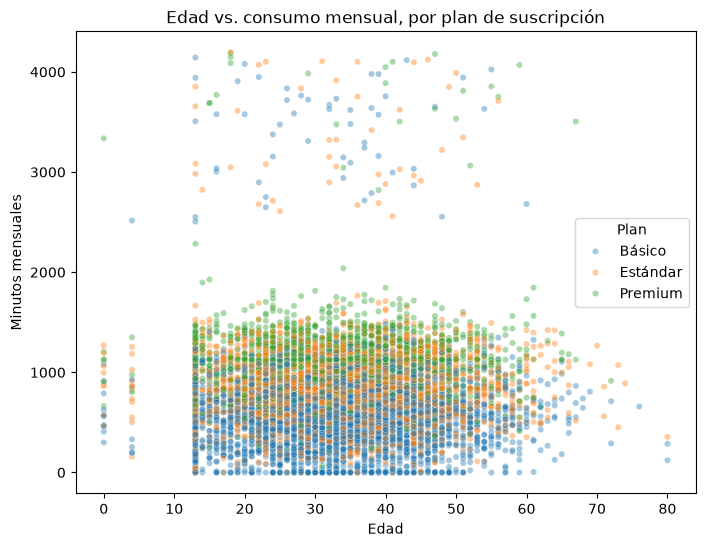

In [43]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='age', y='monthly_watch_time_mins', hue='subscription_plan',
                hue_order=ORDEN_PLAN, alpha=0.4, s=20)
plt.title('Edad vs. consumo mensual, por plan de suscripción')
plt.xlabel('Edad')
plt.ylabel('Minutos mensuales')
plt.legend(title='Plan')
plt.show()

In [44]:
# Correlación edad-consumo, calculada DENTRO de cada plan
for plan in ORDEN_PLAN:
    sub = df[df['subscription_plan'] == plan]
    r = sub['age'].corr(sub['monthly_watch_time_mins'])
    print(f"{plan}: correlación age-watch_time = {r:.3f}")

Básico: correlación age-watch_time = -0.006
Estándar: correlación age-watch_time = 0.010
Premium: correlación age-watch_time = 0.026


**Interpretación:** los tres planes forman bandas horizontales claramente separadas
(Premium arriba, Básico abajo) — confirma lo que vimos en la Pregunta 3, ahora viendo que esa
separación se mantiene en **todas las edades**, no solo en algunas. Dentro de cada plan, la
correlación entre edad y consumo es prácticamente nula (todas cerca de 0): la edad **no**
explica el consumo, el plan sí. Esto descarta una hipótesis razonable (que los usuarios más
jóvenes consumen más contenido) y refuerza que `subscription_plan` es la variable que mejor
organiza el comportamiento de uso en este dataset.
